In [1]:
!pip install evaluate
from datasets import load_dataset, Dataset
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate
from sklearn.utils.class_weight import compute_class_weight

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [2]:
# Load annotated file
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("krio_annotation.csv", encoding='latin1', sep='\t')
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

print("Krio Label Distribution:")
print(df['label'].value_counts())

# Split
from sklearn.model_selection import train_test_split
few_shot_df, test_df = train_test_split(df, test_size=0.75, random_state=42, stratify=df['label'])

few_shot_dataset = Dataset.from_pandas(few_shot_df)
test_dataset = Dataset.from_pandas(test_df)

Saving krio_annotation.csv to krio_annotation.csv
Krio Label Distribution:
label
1    116
0     45
2     39
Name: count, dtype: int64


## Class Weights and Training

In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.array([0, 1, 2])
class_weights = compute_class_weight('balanced', classes=classes, y=df['label'])

# Determine the device dynamically
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights (Negative, Neutral, Positive):", class_weights)

# Trainning with Class Weights
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = evaluate.load("accuracy").compute(predictions=predictions, references=labels)["accuracy"]
    f1 = evaluate.load("f1").compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

models = ["bert-base-multilingual-cased", "xlm-roberta-base"]
results = {}

for model_id in models:
    model_name = "mBERT" if "bert" in model_id else "XLM-R"
    print(f"\nTraining {model_name} with Class Weights...")

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    def tokenize_fn(examples):
        return tokenizer(examples['text_krio'], padding="max_length", truncation=True, max_length=128)

    few_shot_tokenized = few_shot_dataset.map(tokenize_fn, batched=True)
    test_tokenized = test_dataset.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3).to(device)

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}_weighted",
        eval_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        num_train_epochs=4,
        weight_decay=0.01,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=few_shot_tokenized.select(range(min(50, len(few_shot_tokenized)))),
        eval_dataset=test_tokenized,
        compute_metrics=compute_metrics,
    )

    # Use class weights in loss
    trainer.model.config.problem_type = "single_label_classification"

    trainer.train()
    eval_results = trainer.evaluate()

    results[model_name] = eval_results
    print(f"{model_name} - Accuracy: {eval_results['eval_accuracy']:.4f} | Macro F1: {eval_results['eval_macro_f1']:.4f}")

print("\nReautlts With Class Weights")
for name, res in results.items():
    print(f"{name}: Accuracy = {res['eval_accuracy']:.4f}, Macro F1 = {res['eval_macro_f1']:.4f}")

Class Weights (Negative, Neutral, Positive): tensor([1.4815, 0.5747, 1.7094])

Training mBERT with Class Weights...


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/

...

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argumen

Step,Training Loss


mBERT - Accuracy: 0.5800 | Macro F1: 0.2447

Reautlts With Class Weights
mBERT: Accuracy = 0.5800, Macro F1 = 0.2447


## Balanced Few-shot Training

In [10]:
from sklearn.utils import resample

# Create balanced few-shot dataset (max 50 examples)
def create_balanced_fewshot(df, n_per_class=16):
    balanced = []
    for label in [0, 1, 2]:
        subset = df[df['label'] == label]
        if len(subset) > 0:
            sampled = resample(subset, n_samples=min(n_per_class, len(subset)), random_state=42, replace=False)
            balanced.append(sampled)
    return pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)

balanced_df = create_balanced_fewshot(few_shot_df, n_per_class=16)
print("Balanced Few-shot Distribution:")
print(balanced_df['label'].value_counts())

balanced_dataset = Dataset.from_pandas(balanced_df)

# Training With Balanced Sampling

results_balanced = {}

for model_id in ["bert-base-multilingual-cased", "xlm-roberta-base"]:
    model_name = "mBERT" if "bert" in model_id else "XLM-R"
    print(f"\nTraining {model_name} with Balanced Few-shot...")

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    def tokenize_fn(examples):
        return tokenizer(examples['text_krio'], padding="max_length", truncation=True, max_length=128)

    balanced_tokenized = balanced_dataset.map(tokenize_fn, batched=True)
    test_tokenized = test_dataset.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}_balanced",
        eval_strategy="no",
        save_strategy="no", # Still set to 'no' as we will manually save after training
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        num_train_epochs=4,
        weight_decay=0.01,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=balanced_tokenized,
        eval_dataset=test_tokenized,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Manually save the model after training
    trainer.save_model(training_args.output_dir)

    results_balanced[model_name] = eval_results
    print(f"{model_name} - Accuracy: {eval_results['eval_accuracy']:.4f} | Macro F1: {eval_results['eval_macro_f1']:.4f}")

print("\n=== RESULTS WITH BALANCED SAMPLING ===")
for name, res in results_balanced.items():
    print(f"{name}: Accuracy = {res['eval_accuracy']:.4f}, Macro F1 = {res['eval_macro_f1']:.4f}")

Balanced Few-shot Distribution:
label
1    16
0    11
2    10
Name: count, dtype: int64

Training mBERT with Balanced Few-shot...


Map:   0%|          | 0/37 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argumen

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

mBERT - Accuracy: 0.4533 | Macro F1: 0.3238

=== RESULTS WITH BALANCED SAMPLING ===
mBERT: Accuracy = 0.4533, Macro F1 = 0.3238


## Error Analysis

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Overall Accuracy: 0.2267


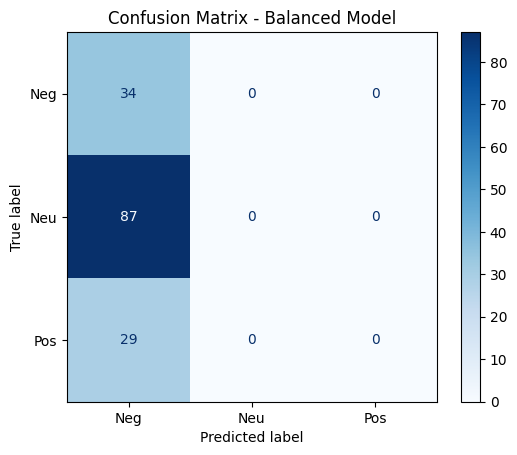


Misclassified Examples


Text: Chif yu no se a l?k yu vilej ?n mi na yu b?sfr?n, so a wan mek sh? se a kam yu awoj?...
True: Positive → Predicted: Negative
Eng Ref: Brother Spider was a greedy person.
There was a time when four villages had a feast on the same day.
All the chiefs in the four villages called Brothe...

Text: Atikul Twenti Nayn
?vrib?di g?t in yon wok we in f? du na in sosayti f? mek sh? se i go liv api ?n ful layf insay de...
True: Neutral → Predicted: Negative
Eng Ref: Thank you thank you
We are thanking the united nation high comission for human rights who did all this work.
The national commission for democracy and...

Text: L? man kik b?l f?s ya!
Sami ple fr?m we skul k?m?t te ples dak...
True: Positive → Predicted: Negative
Eng Ref: Sammy and Sarah had history homework one day.
The teacher gave them the assignmwnt one wednesday afternoon and told them to present it the next mornin...

Text: Kam na Yu YON ?l, et o'kl?k, Tyusde ?n W?nsde, afpas s?vin na n?t...
Tru

In [14]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoConfig

model_path = "./results_mBERT_balanced"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Get predictions on test set
test_tokenized = test_dataset.map(
    lambda examples: tokenizer(examples['text_krio'], padding="max_length", truncation=True, max_length=128), # Use direct tokenization logic
    batched=True
)

trainer = Trainer(model=model, args=TrainingArguments(output_dir="./temp_eval", report_to="none"))
predictions_output = trainer.predict(test_tokenized)

preds = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

# Create detailed error dataframe
error_df = pd.DataFrame({
    'text_krio': test_df['text_krio'].values,
    'true_label': labels,
    'predicted_label': preds,
    'text_english': test_df.get('text_english', None)
})

error_df['true_label_name'] = error_df['true_label'].map({0:'Negative', 1:'Neutral', 2:'Positive'})
error_df['pred_label_name'] = error_df['predicted_label'].map({0:'Negative', 1:'Neutral', 2:'Positive'})
error_df['correct'] = error_df['true_label'] == error_df['predicted_label']

print(f"Overall Accuracy: {error_df['correct'].mean():.4f}")

# Confusion Matrix
cm = confusion_matrix(error_df['true_label'], error_df['predicted_label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Neu', 'Pos'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Balanced Model')
plt.show()

# Save confusion matrix
os.makedirs("./error_analysis", exist_ok=True)
pd.DataFrame(cm,
             index=['True Neg', 'True Neu', 'True Pos'],
             columns=['Pred Neg', 'Pred Neu', 'Pred Pos']).to_csv("./error_analysis/confusion_matrix_balanced.csv")

# Misclassified Examples
print("\nMisclassified Examples\n")
misclassified = error_df[error_df['correct'] == False].sample(min(12, len(error_df[error_df['correct']==False])))

for i, row in misclassified.iterrows():
    print(f"\nText: {row['text_krio'][:180]}...")
    print(f"True: {row['true_label_name']} → Predicted: {row['pred_label_name']}")
    if pd.notna(row.get('text_english')):
        print(f"Eng Ref: {str(row['text_english'])[:150]}...")

# Save detailed error analysis dataframe
error_df.to_csv("./error_analysis/error_analysis_balanced.csv", index=False)
print("\nAll error analysis files saved in './error_analysis/' folder")